# Import Bathymetric Digital Elevation Models
The following code imports digital elevation models (DEMs) that are organized in the [ArcGIS Pro Atlas](./ArcGIS%20Projects/CCFRP%20CSMP%20Bathymetry%20Atlas/)
 on this local drive. 

Install the following Python packages into your working environment before importing into this notebook.  

In [1]:
import matplotlib.pyplot as plt
import geopandas as gpd
import xdem
import os
import rioxarray as rxr

import rasterio
import numpy as np
import xarray as xr
from rasterio.features import geometry_mask
from rasterio.warp import calculate_default_transform, reproject, Resampling

## I. Clean and Prepare DEMs and Shapefile for Analysis

Make a list of the raw DEM .tif files that I want to use as the inputs for calculating habitat metrics with xDEM. 

In [2]:
dem_folder = "DEMs"
dem_list = []

for file_name in os.listdir(dem_folder):
    if file_name[-4:] == '.tif':
        dem_list.append(file_name)

print(dem_list)

['AnoNuevo_Bathymetry.tif', 'BodegaHead_Bathymetry.tif', 'CarringtonPoint_Bathymetry.tif', 'LagunaBeach_Bathymetry.tif', 'PiedrasBlancas_Bathymetry.tif', 'PointBuchon_Bathymetry.tif', 'PointConception_Bathymetry.tif', 'PointLobos_Bathymetry.tif', 'SouthCapeMendocino_Bathymetry.tif', 'SoutheastFarallonIsland_Bathymetry.tif', 'SouthLaJolla_Bathymetry.tif', 'StewartsPoint_Bathymetry.tif', 'Swamis_Bathymetry.tif']


Ensure that all DEMs are in the same projection and resoltion. 

In [ ]:
dem_folder = "DEMs"  
output_reprojected = "DEM_reprojected"
output_terrainified = "DEM_terrainified"  # output folder for terrainified DEMs
target_crs = "EPSG:26910"
target_resolution = (2.0, 2.0) 
nodata_value = np.nan

os.makedirs(output_reprojected, exist_ok=True)
os.makedirs(output_terrainified, exist_ok=True)

dem_list = [f for f in os.listdir(dem_folder) if f.endswith(".tif")]

# ----------------------------
# Reproject DEMs
# ----------------------------
for file_name in dem_list:
    input_path = os.path.join(dem_folder, file_name)
    reprojected_path = os.path.join(output_reprojected, file_name.replace('.tif', '_reprojected.tif'))
    terrainified_path = os.path.join(output_terrainified, file_name.replace('.tif', '_terrainified.tif'))

    with rasterio.open(input_path) as src:
        transform, width, height = calculate_default_transform(
            src.crs, target_crs, src.width, src.height, *src.bounds, resolution=target_resolution
        )

        kwargs = src.meta.copy()
        kwargs.update({
            "crs": target_crs,
            "transform": transform,
            "width": width,
            "height": height,
            "dtype": 'float32',
            "nodata": nodata_value
        })

        # Reproject raster
        reprojected_data = np.empty((src.count, height, width), dtype=np.float32)
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=reprojected_data[i-1],
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=target_crs,
                resampling=Resampling.bilinear
            )

        with rasterio.open(reprojected_path, "w", **kwargs) as dst:
            dst.write(reprojected_data)

        print(f"Reprojected: {reprojected_path}")

    # ----------------------------
    # Terrainifying section (comment out if not needed)
    # ----------------------------
    """
    # Only terrainify if there are negative values
    data = reprojected_data[0].copy()  # first band
    is_bathymetric = data < 0
    if not np.any(is_bathymetric):
        print(f"Skipping terrainify for {file_name} (no negative values).")
    else:
        min_depth = np.nanmin(data[is_bathymetric])
        terrainified = np.full_like(data, np.nan, dtype=np.float32)
        terrainified[is_bathymetric] = data[is_bathymetric] - min_depth

        profile = kwargs.copy()
        profile.update(count=1)
        with rasterio.open(terrainified_path, "w", **profile) as dst:
            dst.write(terrainified, 1)

        print(f"Terrainified: {terrainified_path}")
    """

In [5]:
dem_folder = "DEMs"  
output_folder = "DEM_reprojected" 
target_crs = "EPSG:26910"
target_resolution = (2.0, 2.0) 

for file_name in dem_list:
    input_path = os.path.join(dem_folder, file_name)
    output_path = os.path.join(output_folder, file_name.replace('.tif', '_reprojected.tif'))

    with rasterio.open(input_path) as src:
        transform, width, height = calculate_default_transform(
            src.crs, target_crs, src.width, src.height, *src.bounds, resolution=target_resolution
        )

        # Copy and update metadata
        kwargs = src.meta.copy()
        kwargs.update({
            "crs": target_crs,
            "transform": transform,
            "width": width,
            "height": height
        })

        # Save the reprojected raster
        with rasterio.open(output_path, "w", **kwargs) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs=target_crs,
                    resampling=Resampling.bilinear  # You can use Resampling.nearest if you prefer
                )

Now, we want to make sure that e are only dealing with values that are under water (e.g. depth values > 0). However, the package that we are using to generate habitat metrics is usually applied to above ground DEMs. Therefore, I will also invert the depth data to resemble above ground topography. 

In [6]:
dem_reprojected = "DEM_reprojected"
dem_terrainified = "DEM_terrainified"
nodata_value = np.nan
os.makedirs(dem_terrainified, exist_ok=True)

dem_reprojected_list = []
for file_name in os.listdir(dem_reprojected):
    if file_name[-4:] == '.tif':
        dem_reprojected_list.append(file_name)


for file_name in dem_reprojected_list:
    input_path = os.path.join(dem_reprojected, file_name)
    output_path = os.path.join(dem_terrainified, file_name.replace('.tif', '_terrainified.tif'))

    with rasterio.open(input_path) as src:
        profile = src.profile.copy()
        data = src.read(1).astype(np.float32)
        if src.nodata is not None:
            data[data == src.nodata] = np.nan

        is_bathymetric = data < 0
        if not np.any(is_bathymetric):
            print(f"Skipping {file_name} (no negative values).")
            continue

        min_depth = np.nanmin(data[is_bathymetric])
        terrainified = np.full_like(data, np.nan)
        terrainified[is_bathymetric] = data[is_bathymetric] - min_depth

        profile.update(dtype='float32', nodata=nodata_value)

        with rasterio.open(output_path, "w", **profile) as dst:
            dst.write(terrainified, 1)

        print(f"Saved: {output_path}")


Saved: DEM_terrainified\AnoNuevo_Bathymetry_reprojected_terrainified.tif
Saved: DEM_terrainified\BodegaHead_Bathymetry_reprojected_terrainified.tif
Saved: DEM_terrainified\CarringtonPoint_Bathymetry_reprojected_terrainified.tif
Saved: DEM_terrainified\LagunaBeach_Bathymetry_reprojected_terrainified.tif
Saved: DEM_terrainified\PiedrasBlancas_Bathymetry_reprojected_terrainified.tif


KeyboardInterrupt: 

We'll also want to make sure that the shapefile of the CCFRP-sampled grid cells is cleaned up before we perform zonal statistics. 

Connect to local database to access habitat metric files created in [02_Organize_DEMs](Python/02_Organize_DEMs.ipynb) Jupyter Notebook, as well as the [shapefile of CCFRP gridcells](Python/Shapefiles/CCFRP_Grid_Cells/CCFRP_Grid_cell.shp). Then, we need to make sure the habitat metric rasters and grid cell shapefile are in the same coordinate reference system.

First, we will need to build a naming map to associate the coded area names in the shapfile to the names of the xDEM habitat rasters. Let's also reproject the shapefile to our working CRS while were at it. 

In [10]:
# Define path to grid cell shapefile 
grid_cells_shp = "Shapefiles/CCFRP_Grid_Cells/CCFRP_Grid_cell.shp"
grid_cells = gpd.read_file(grid_cells_shp)

# Define path to create a reprojected shapefile 
reprojected_shapefile_path = os.path.join("Shapefiles/CCFRP_Grid_Cells_reprojected", 
                                          "CCFRP_Grid_Cells_reprojected.shp")

# This is the target CRS we used to unify all the habitat metric DEMs 
target_crs = "EPSG:26910"

#Reproject! 
grid_cells_reprojected = grid_cells.to_crs(target_crs)
grid_cells_reprojected.to_file(reprojected_shapefile_path)

# Mapping of area codes to full names
area_name_map = {
    "AI": "Anacapa Island",
    "AN": "Ano Nuevo",
    "BH": "Bodega Head", 
    "BL": "Piedras Blancas",
    "CM": "South Cape Mendocino",
    "CP": "Carrington Point",
    "FN": "Southeast Farallon Island",
    "LB": "Laguna Beach",
    "LJ": "South La Jolla",
    "PB": "Point Buchon", 
    "PC": "Point Conception",
    "PL": "Point Lobos",
    "SP": "Stewarts Point",
    "SW": "Swamis",
    "TM": "Ten Mile",
    "TD": "Trinidad"
}

grid_cells['Full_Area'] = grid_cells['Area'].map(area_name_map)

# Preview the result
grid_cells[['Area', 'Full_Area']]

,Area,Full_Area
0,LJ,South La Jolla
1,LJ,South La Jolla
2,LJ,South La Jolla
3,LJ,South La Jolla
4,LJ,South La Jolla
...,...,...
428,TD,Trinidad
429,TD,Trinidad
430,TD,Trinidad
431,TD,Trinidad


## II. Calculate Habitat Metrics with xDEM

Define which habitat attributes I would like to calculate, and calculate my list of specified habitat attributes for each of my DEMs of interest. Details on each metric and how it is calculated by xDEM can be found on the ['Terrain attributes' page on the xDEM website](https://xdem.readthedocs.io/en/stable/terrain.html).

In [9]:
habitat_attributes = ["slope", 
                      "aspect", 
                      "curvature", 
                      "planform_curvature", 
                      "profile_curvature", 
                      "topographic_position_index", 
                      "terrain_ruggedness_index", 
                      "roughness", 
                      "rugosity", 
                      "fractal_roughness"]

Create a list of the reprojected DEMs for xDEM to calculate habitat metrics from. Some of the equations under the hood for xDEM require that pixels be square, for example. It's also important that we get all the DEMs into the same CRS before performing these equations. 

In [39]:
dem_reprojected = "DEM_reprojected"
dem_reprojected_list = []

for file_name in os.listdir(dem_reprojected):
    if file_name[-4:] == '.tif':
        dem_reprojected_list.append(file_name)

print(dem_reprojected_list)

['AnoNuevo_Bathymetry_reprojected.tif', 'BodegaHead_Bathymetry_reprojected.tif', 'CarringtonPoint_Bathymetry_reprojected.tif', 'LagunaBeach_Bathymetry_reprojected.tif', 'PiedrasBlancas_Bathymetry_reprojected.tif', 'PointBuchon_Bathymetry_reprojected.tif', 'PointConception_Bathymetry_reprojected.tif', 'PointLobos_Bathymetry_reprojected.tif', 'SouthCapeMendocino_Bathymetry_reprojected.tif', 'SoutheastFarallonIsland_Bathymetry_reprojected.tif', 'SouthLaJolla_Bathymetry_reprojected.tif', 'StewartsPoint_Bathymetry_reprojected.tif', 'Swamis_Bathymetry_reprojected.tif']


Define an output directory to contain rasters of habitat metrics calculated using xDEM. 

In [12]:
output_dir = "xDEM_Rasters"
os.makedirs(output_dir, exist_ok=True)

Finally, we calculate the above defined habitat attributes using xDEM, and export the resultant rasters into the output folder that we identified above. This code also renames each file to reflect the habitat attribute being described at each location. 

In [9]:
for dem_name in dem_reprojected_list:
    dem_path = os.path.join(dem_reprojected, dem_name)
    print(f"Calculating habitat attributes for: {dem_name}")

    dem = xdem.DEM(dem_path)

    for attribute in habitat_attributes:
        kwargs = {}

        # Use different window size for fractal roughness - default is 13
        if attribute == "fractal_roughness":
            kwargs["window_size"] = 13  # Or higher, if desired

        # Compute terrain attribute
        data_np = xdem.terrain.get_terrain_attribute(
            dem.data,
            resolution=dem.res,
            attribute=attribute,
            **kwargs  # Only passed if needed
        )

        # Clean and format output
        data_np = np.nan_to_num(data_np, nan=-9999, posinf=-9999, neginf=-9999)
        data_np = data_np.astype(np.float32)  # Force float32 to be safe for GIS

        # Copy DEM and update data
        ddem = dem.copy()
        ddem.data = data_np
        ddem.nodata = -9999  # Explicitly set nodata

        # Build output path
        site_name = os.path.splitext(dem_name)[0].split("_")[0]
        out_path = os.path.join(output_dir, f"{site_name}_{attribute}.tif")

        # Save the attribute raster
        ddem.save(out_path)

print("Habitat attribute calculation complete.")

Calculating habitat attributes for: AnoNuevo_Bathymetry_reprojected_terrainified.tif


C:\Users\FELAB\miniconda3\Lib\site-packages\geoutils\raster\raster.py:1625: UserWarning: New nodata value cells already exist in the data array. These cells will now be masked, and the old nodata value cells will update to the same new value. Use set_nodata() with update_array=False or update_mask=False to change this behaviour.
  warnings.warn(
C:\Users\FELAB\miniconda3\Lib\site-packages\geoutils\raster\raster.py:1625: UserWarning: New nodata value cells already exist in the data array. These cells will now be masked, and the old nodata value cells will update to the same new value. Use set_nodata() with update_array=False or update_mask=False to change this behaviour.
  warnings.warn(
C:\Users\FELAB\miniconda3\Lib\site-packages\geoutils\raster\raster.py:1625: UserWarning: New nodata value cells already exist in the data array. These cells will now be masked, and the old nodata value cells will update to the same new value. Use set_nodata() with update_array=False or update_mask=False

Calculating habitat attributes for: BodegaHead_Bathymetry_reprojected_terrainified.tif


C:\Users\FELAB\miniconda3\Lib\site-packages\geoutils\raster\raster.py:1625: UserWarning: New nodata value cells already exist in the data array. These cells will now be masked, and the old nodata value cells will update to the same new value. Use set_nodata() with update_array=False or update_mask=False to change this behaviour.
  warnings.warn(
C:\Users\FELAB\miniconda3\Lib\site-packages\geoutils\raster\raster.py:1625: UserWarning: New nodata value cells already exist in the data array. These cells will now be masked, and the old nodata value cells will update to the same new value. Use set_nodata() with update_array=False or update_mask=False to change this behaviour.
  warnings.warn(
C:\Users\FELAB\miniconda3\Lib\site-packages\geoutils\raster\raster.py:1625: UserWarning: New nodata value cells already exist in the data array. These cells will now be masked, and the old nodata value cells will update to the same new value. Use set_nodata() with update_array=False or update_mask=False

Calculating habitat attributes for: CarringtonPoint_Bathymetry_reprojected_terrainified.tif


...

Calculating habitat attributes for: StewartsPoint_Bathymetry_reprojected_terrainified.tif


C:\Users\FELAB\miniconda3\Lib\site-packages\geoutils\raster\raster.py:1625: UserWarning: New nodata value cells already exist in the data array. These cells will now be masked, and the old nodata value cells will update to the same new value. Use set_nodata() with update_array=False or update_mask=False to change this behaviour.
  warnings.warn(
C:\Users\FELAB\miniconda3\Lib\site-packages\geoutils\raster\raster.py:1625: UserWarning: New nodata value cells already exist in the data array. These cells will now be masked, and the old nodata value cells will update to the same new value. Use set_nodata() with update_array=False or update_mask=False to change this behaviour.
  warnings.warn(
C:\Users\FELAB\miniconda3\Lib\site-packages\geoutils\raster\raster.py:1625: UserWarning: New nodata value cells already exist in the data array. These cells will now be masked, and the old nodata value cells will update to the same new value. Use set_nodata() with update_array=False or update_mask=False

Calculating habitat attributes for: Swamis_Bathymetry_reprojected_terrainified.tif


C:\Users\FELAB\miniconda3\Lib\site-packages\geoutils\raster\raster.py:1625: UserWarning: New nodata value cells already exist in the data array. These cells will now be masked, and the old nodata value cells will update to the same new value. Use set_nodata() with update_array=False or update_mask=False to change this behaviour.
  warnings.warn(
C:\Users\FELAB\miniconda3\Lib\site-packages\geoutils\raster\raster.py:1625: UserWarning: New nodata value cells already exist in the data array. These cells will now be masked, and the old nodata value cells will update to the same new value. Use set_nodata() with update_array=False or update_mask=False to change this behaviour.
  warnings.warn(
C:\Users\FELAB\miniconda3\Lib\site-packages\geoutils\raster\raster.py:1625: UserWarning: New nodata value cells already exist in the data array. These cells will now be masked, and the old nodata value cells will update to the same new value. Use set_nodata() with update_array=False or update_mask=False

Habitat attribute calculation complete.


Here is some specific code for generating fractal roughness with windows of varying size. 

In [40]:
dem_reprojected_list

['AnoNuevo_Bathymetry_reprojected.tif',
 'BodegaHead_Bathymetry_reprojected.tif',
 'CarringtonPoint_Bathymetry_reprojected.tif',
 'LagunaBeach_Bathymetry_reprojected.tif',
 'PiedrasBlancas_Bathymetry_reprojected.tif',
 'PointBuchon_Bathymetry_reprojected.tif',
 'PointConception_Bathymetry_reprojected.tif',
 'PointLobos_Bathymetry_reprojected.tif',
 'SouthCapeMendocino_Bathymetry_reprojected.tif',
 'SoutheastFarallonIsland_Bathymetry_reprojected.tif',
 'SouthLaJolla_Bathymetry_reprojected.tif',
 'StewartsPoint_Bathymetry_reprojected.tif',
 'Swamis_Bathymetry_reprojected.tif']

In [41]:
dem_reprojected = "DEM_reprojected"

for dem_name in dem_reprojected_list:
    dem_path = os.path.join(dem_reprojected, dem_name)
    print(f"Calculating fractal roughness for: {dem_name}")

    dem = xdem.DEM(dem_path)

    # Only compute fractal roughness
    attribute = "fractal_roughness"
    kwargs = {"window_size": 7}

    data_np = xdem.terrain.get_terrain_attribute(
        dem.data,
        resolution=dem.res,
        attribute=attribute,
        **kwargs
    )

    # Clean and format output
    data_np = np.nan_to_num(data_np, nan=-9999, posinf=-9999, neginf=-9999)
    data_np = data_np.astype(np.float32)

    # Copy DEM and update data
    ddem = dem.copy()
    ddem.data = data_np
    ddem.nodata = -9999

    # Build output path
    site_name = os.path.splitext(dem_name)[0].split("_")[0]
    out_path = os.path.join(output_dir, f"{site_name}_{attribute}.tif")

    # Overwrite if file exists
    if os.path.exists(out_path):
        os.remove(out_path)

    # Save the attribute raster
    ddem.save(out_path)

print("Fractal roughness calculation complete.")


Calculating fractal roughness for: AnoNuevo_Bathymetry_reprojected.tif


C:\Users\FELAB\miniconda3\Lib\site-packages\geoutils\raster\raster.py:1625: UserWarning: New nodata value cells already exist in the data array. These cells will now be masked, and the old nodata value cells will update to the same new value. Use set_nodata() with update_array=False or update_mask=False to change this behaviour.
  warnings.warn(


NameError: name 'output_dir' is not defined

## III. Visualize newly generated habitat metrics! 

Define the files you want to display and their location. 

In [28]:
# Folder containing precomputed terrain metric rasters
folder_path = "xDEM_Rasters"

# Paths to MPA and grid cell shapefiles, and project them to our target CRS for our area of interest, in this case AN
mpa_shapefile = gpd.read_file("Shapefiles/CCFRP_MPAs/ccfrp_mpas.shp").to_crs(target_crs)
mpa_AN = mpa_shapefile[mpa_shapefile["NAME"] == "Año Nuevo SMR"]

grid_cell_shapefile = gpd.read_file("Shapefiles/CCFRP_Grid_Cells_reprojected/CCFRP_Grid_Cells_reprojected.shp").to_crs(target_crs)
grid_cell_AN = grid_cell_shapefile[grid_cell_shapefile["Area"] == "AN"]


# Define the habitat metrics and area that you want to plot 
attributes = ["slope", "topographic_position_index", "terrain_ruggedness_index", "rugosity"]
location = "AnoNuevo"

# GEnerate a list of the paths to the corresponding rasters 
file_list = []

for attribute in attributes: 
    file_name = f"{folder_path}/{location}_{attribute}.tif"
    file_list.append(file_name)

file_list

['xDEM_Rasters/AnoNuevo_slope.tif',
 'xDEM_Rasters/AnoNuevo_topographic_position_index.tif',
 'xDEM_Rasters/AnoNuevo_terrain_ruggedness_index.tif',
 'xDEM_Rasters/AnoNuevo_rugosity.tif']

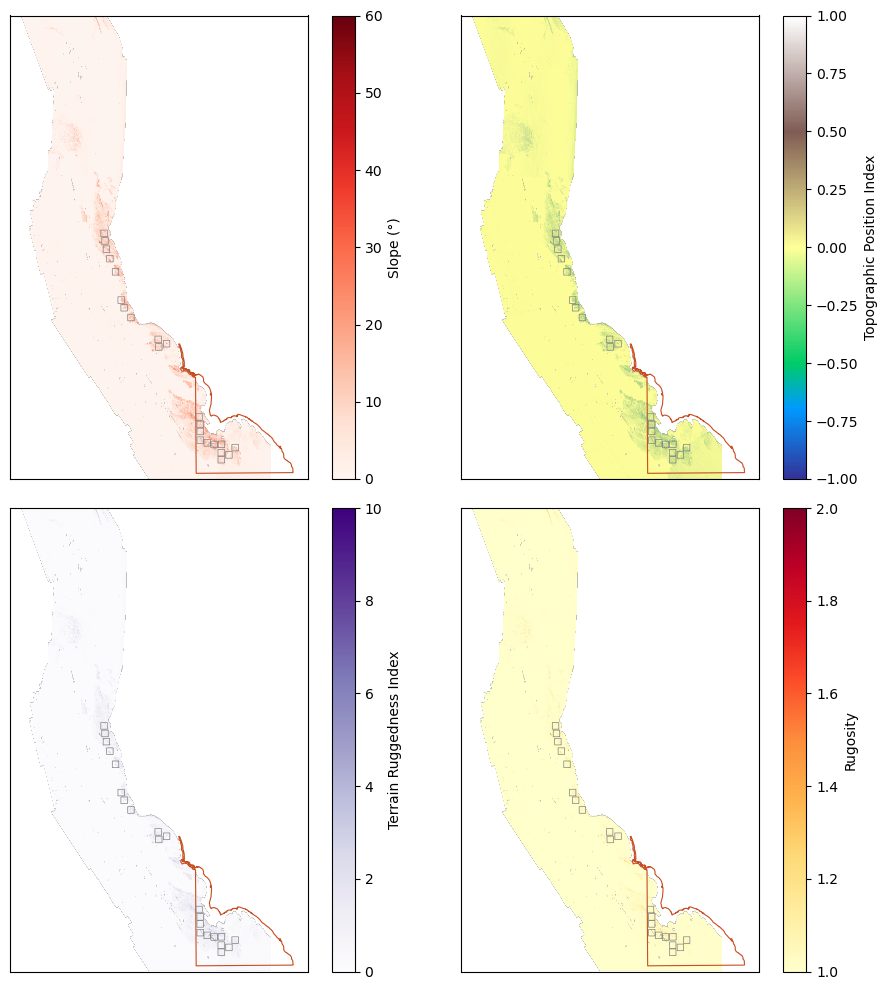

In [37]:
# File paths for raster and vector data
folder_path = "xDEM_Rasters"
attributes = ["slope", "topographic_position_index", "terrain_ruggedness_index", "rugosity"]
location = "AnoNuevo"
file_list = [f"{folder_path}/{location}_{attr}.tif" for attr in attributes]

# Vector layers (make sure target_crs is defined)
mpa_shapefile = gpd.read_file("Shapefiles/CCFRP_MPAs/ccfrp_mpas.shp").to_crs(target_crs)
mpa_AN = mpa_shapefile[mpa_shapefile["NAME"] == "Año Nuevo SMR"]

grid_cell_shapefile = gpd.read_file("Shapefiles/CCFRP_Grid_Cells_reprojected/CCFRP_Grid_Cells_reprojected.shp").to_crs(target_crs)
grid_cell_AN = grid_cell_shapefile[grid_cell_shapefile["Area"] == "AN"]


# Plot settings
cmaps = ["Reds", "terrain", "Purples", "YlOrRd"]
labels = ["Slope (°)", "Topographic Position Index", "Terrain Ruggedness Index", "Rugosity"]
vlims = [(0, 60), (-1, 1), (0, 10), (1, 2)]

plt.figure(figsize=(10, 10))

for i, file_path in enumerate(file_list):
    with rasterio.open(file_path) as src:
        data = src.read(1)
        extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

        # Mask NaNs or nodata
        if src.nodata is not None:
            data = np.ma.masked_equal(data, src.nodata)
        else:
            data = np.ma.masked_invalid(data)

    ax = plt.subplot(2, 2, i + 1)
    img = ax.imshow(data, cmap=cmaps[i], extent=extent, vmin=vlims[i][0], vmax=vlims[i][1])
    
    # Overlay MPA and grid boundaries
    mpa_AN.boundary.plot(ax=ax, edgecolor="#C74E22", linewidth=.8)
    grid_cell_AN.boundary.plot(ax=ax, edgecolor="grey", linewidth=0.5)
    
    plt.colorbar(img, ax=ax, label=labels[i])
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()

output_path = f"WSN_Figures/xDEM_rasters.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
